# EDA: HTRU2 Pulsar Star Detection

## Task
Binary classification task: given statistical features extracted from
radio telescope signals, predict whether a candidate is a real pulsar (1)
or a non-pulsar candidate (0).

Dataset: HTRU2 (High Time Resolution Universe Survey), UCI ML Repository.
17,898 samples, 8 continuous features, highly imbalanced target with a minority positive class.

## Features

Each candidate is described by 8 statistics computed from two signal
representations: the **integrated pulse profile** and the **DM-SNR curve**.

| Column | Description |
|---|---|
| `mean_profile` | Mean intensity of the integrated pulse profile. |
| `std_profile` | Variability of the intensity values in the integrated pulse profile. |
| `kurtosis_profile` | Measures the peakedness and tail heaviness of the profile's intensity distribution. |
| `skewness_profile` | Measures the asymmetry of the profile's intensity distribution. |
| `mean_dm_snr` | Mean signal-to-noise ratio across the DM-SNR curve. |
| `std_dm_snr` | Variability of the signal-to-noise ratio across the DM-SNR curve. |
| `kurtosis_dm_snr` | Measures the peakedness and tail heaviness of the DM-SNR distribution. |
| `skewness_dm_snr` | Measures the asymmetry of the DM-SNR distribution. |
| `target` | Target class: `1` = pulsar, `0` = non-pulsar. |

### Signal representations

**Integrated pulse profile** — the average signal intensity as a function of
pulse phase. A stable and pronounced pulse profile is characteristic of a
pulsar.

**DM-SNR curve** — the signal-to-noise ratio as a function of dispersion
measure (DM). It describes how strongly the signal is detected at different
assumed dispersion measures.

## Why this matters
Manually verifying pulsar candidates from telescope surveys is expensive.
An automated classifier helps filter out the vast majority of non-pulsar candidates so
astronomers can focus on the most promising signals.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT_DIR = Path.cwd().parent
DATA_PATH = ROOT_DIR / "data" / "raw" / "HTRU_2.csv"

## 1. Setup & Load

In [3]:
columns = [
    "mean_profile",
    "std_profile",
    "kurtosis_profile",
    "skewness_profile",
    "mean_dm_snr",
    "std_dm_snr",
    "kurtosis_dm_snr",
    "skewness_dm_snr",
    "target",
]

df = pd.read_csv(DATA_PATH, header=None, names=columns)
df.head(5)

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dm_snr,std_dm_snr,kurtosis_dm_snr,skewness_dm_snr,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [4]:
df.shape

(17898, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean_profile      17898 non-null  float64
 1   std_profile       17898 non-null  float64
 2   kurtosis_profile  17898 non-null  float64
 3   skewness_profile  17898 non-null  float64
 4   mean_dm_snr       17898 non-null  float64
 5   std_dm_snr        17898 non-null  float64
 6   kurtosis_dm_snr   17898 non-null  float64
 7   skewness_dm_snr   17898 non-null  float64
 8   target            17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [6]:
df.describe()

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dm_snr,std_dm_snr,kurtosis_dm_snr,skewness_dm_snr,target
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


### 1.1. Initial observations

- Dataset contains 17,898 samples, 8 continuous features, and 1 binary target.
- No missing values are present -> no imputation is required.
- All feature columns are numeric and the target is stored as an integer.
- Feature scales and ranges vary substantially -> scaling may be relevant for scale-sensitive models.

## 2. Target distribution

### 2.1. Class distribution

Before analyzing the features, we examine the distribution of the target variable to assess whether the dataset is balanced. 
Class imbalance is important because it can affect both model training and the choice of evaluation metrics.

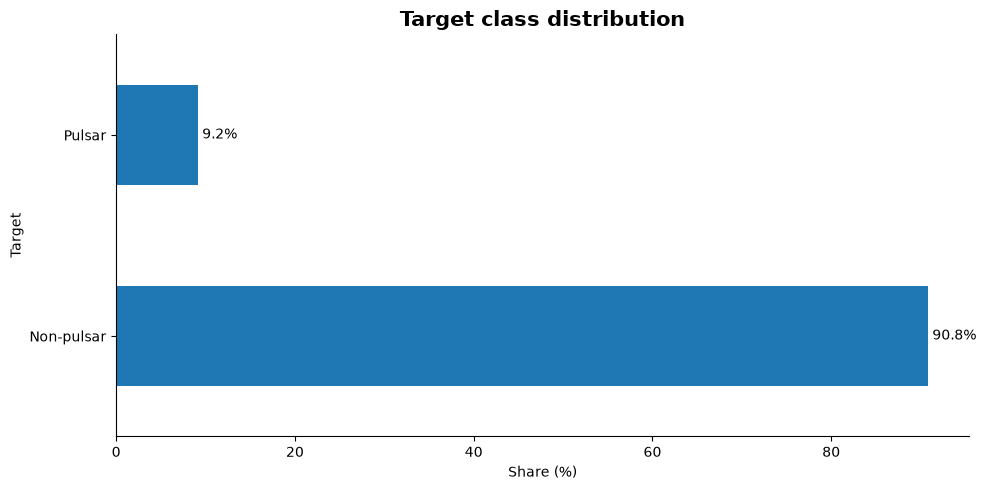

In [7]:
labels = {1: "Pulsar", 0: "Non-pulsar"}
df_plot = df.copy()
df_plot["target"] = df_plot["target"].map(labels)

target_share = df_plot["target"].value_counts(normalize=True).mul(100)
ax = target_share.plot(kind="barh", figsize=(10, 5))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

sns.despine()
plt.xlabel("Share (%)")
plt.ylabel("Target")
plt.title("Target class distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.2. Target distribution - Findings

- 9.2% pulsar candidates vs 90.8% non-pulsars -> the target is strongly imbalanced.
- Accuracy alone may be misleading; recall and PR-AUC should be considered during model evaluation.
- Test imbalance-aware approaches, such as class weights, during the modeling stage.

## 3. Univariate analysis

This section examines the distribution of each numerical feature independently of the target variable. We focus on distribution shape, central tendency, spread, skewness, and potential extreme values.

In [8]:
integrated_pulse_features = ["mean_profile", "std_profile", "kurtosis_profile", "skewness_profile"]
dm_snr_features = ["mean_dm_snr", "std_dm_snr", "kurtosis_dm_snr", "skewness_dm_snr"]

### 3.1. Integrated pulse profile

In [9]:
def plot_feature_distributions(df, features, hue=None):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, feature in zip(axes, features):
        sns.histplot(
            data=df,
            x=feature,
            hue=hue,
            kde=True,
            ax=ax
        )

        ax.set_title(feature, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    fig.suptitle(
        "Feature Distributions",
        fontsize=16,
        fontweight="bold"
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

def analyze_outliers(df, features, hue=None):
    _, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, feature in zip(axes, features):
        sns.boxplot(
            data=df,
            x=feature,
            hue=hue,
            ax=ax
        )

        ax.set_title(f"Boxplot of {feature}", fontsize=12, fontweight="bold")
        ax.set_xlabel(feature)

    sns.despine()
    plt.tight_layout()
    plt.show()

    if hue is not None:
        for feature in features:
            for target_class, group in df.groupby("target"):
                Q1 = group[feature].quantile(0.25)
                Q3 = group[feature].quantile(0.75)

                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR

                outliers = group[(group[feature] < lower) | (group[feature] > upper)]

                print(f"{feature} | class {target_class}:")
                print(f"IQR: {IQR:.2f}")
                print(f"Lower bound: {lower:.2f}")
                print(f"Upper bound: {upper:.2f}")
                print(f"Outliers: {len(outliers)} ({len(outliers) / len(group):.2%})\n")
    else:
        for feature in features:
            Q1 = df[feature].quantile(0.25)
            Q3 = df[feature].quantile(0.75)

            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            outliers = df[(df[feature] < lower) | (df[feature] > upper)]

            print(f"{feature}:")
            print(f"IQR: {IQR:.2f}")
            print(f"Lower bound: {lower:.2f}")
            print(f"Upper bound: {upper:.2f}")
            print(f"Outliers: {len(outliers)} ({len(outliers) / len(df):.2%})\n")

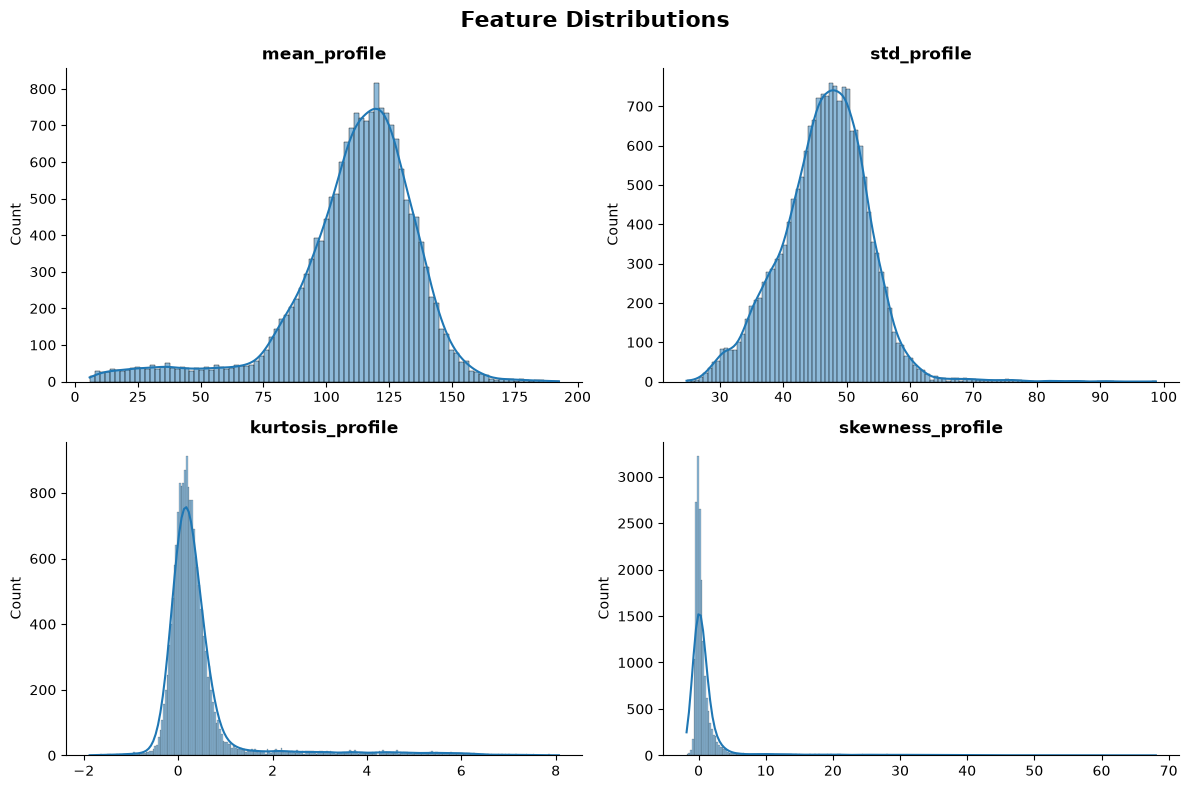

In [10]:
plot_feature_distributions(df, integrated_pulse_features)

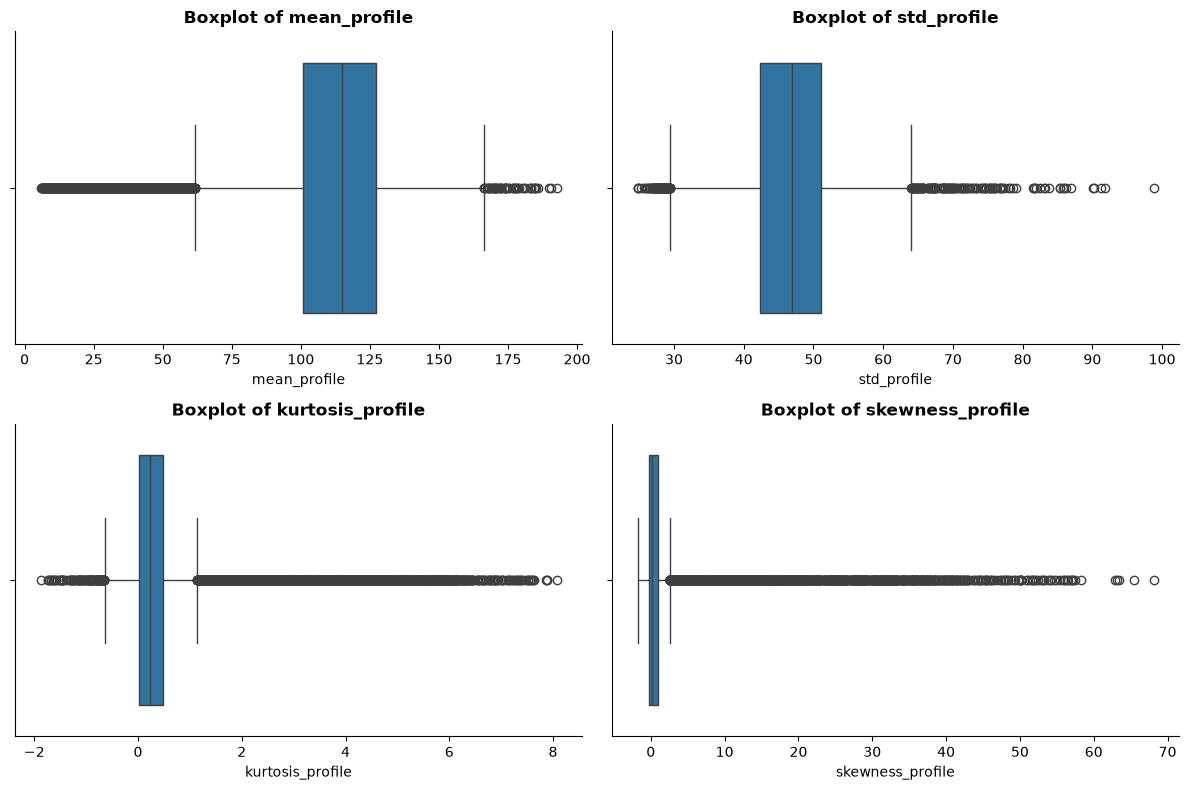

mean_profile:
IQR: 26.16
Lower bound: 61.70
Upper bound: 166.32
Outliers: 1030 (5.75%)

std_profile:
IQR: 8.65
Lower bound: 29.41
Upper bound: 63.99
Outliers: 262 (1.46%)

kurtosis_profile:
IQR: 0.45
Lower bound: -0.64
Upper bound: 1.14
Outliers: 1596 (8.92%)

skewness_profile:
IQR: 1.12
Lower bound: -1.86
Upper bound: 2.60
Outliers: 1901 (10.62%)



In [11]:
analyze_outliers(df, integrated_pulse_features)

### 3.2. Univariate: Integrated Pulse Profile — findings

- `mean_profile` and `std_profile` are unimodal and roughly Gaussian, though `mean_profile` exhibits a noticeable left tail ($< 75$).
- `kurtosis_profile` and `skewness_profile` are extremely right-skewed with heavy tails: IQR outlier rates ($8.92\%$ and $10.62\%$) closely match the target rate ($9.16\%$).
- -> Do not remove outliers: extreme positive values represent the actual minority class (pulsars).
- -> Non-linear transformations (Yeo-Johnson / log-shift) are necessary for linear/distance models due to skewness and negative values.
- -> Candidate feature: relative pulse dispersion via Coefficient of Variation (`std_profile` / `mean_profile`).

### 3.3. DM-SNR curve

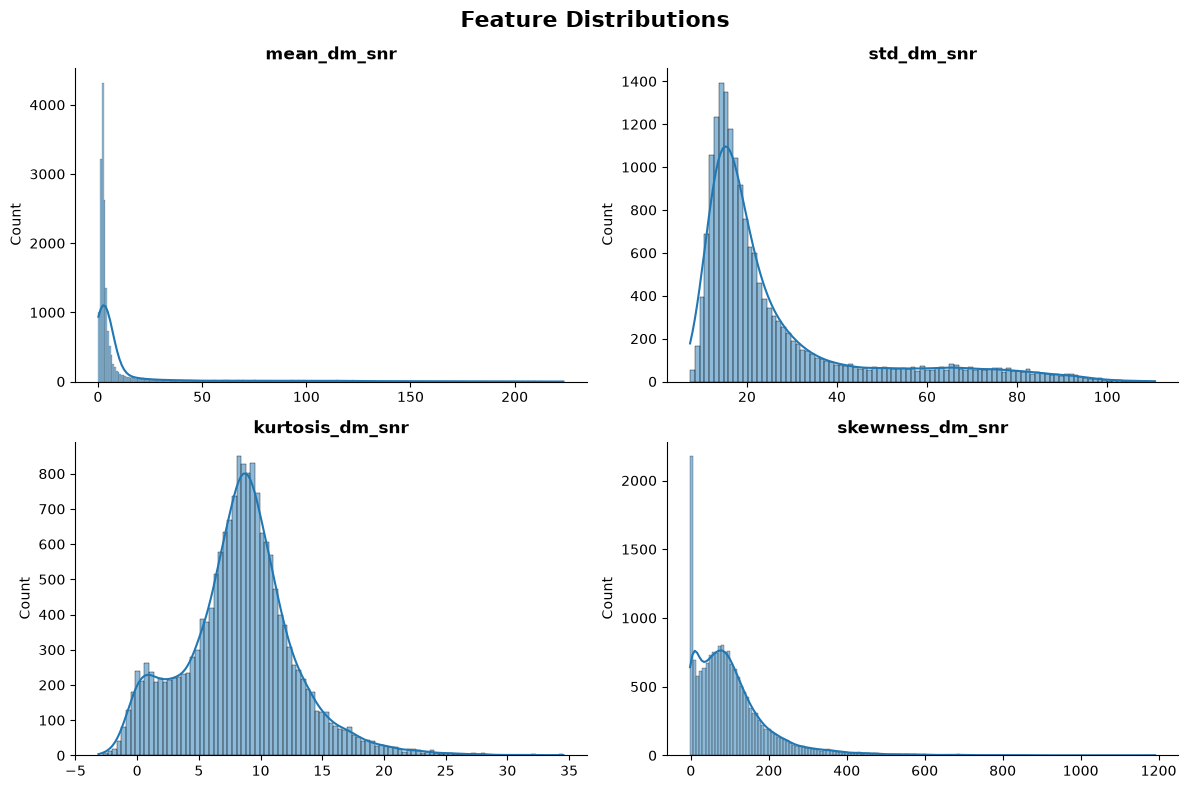

In [12]:
plot_feature_distributions(df, dm_snr_features)

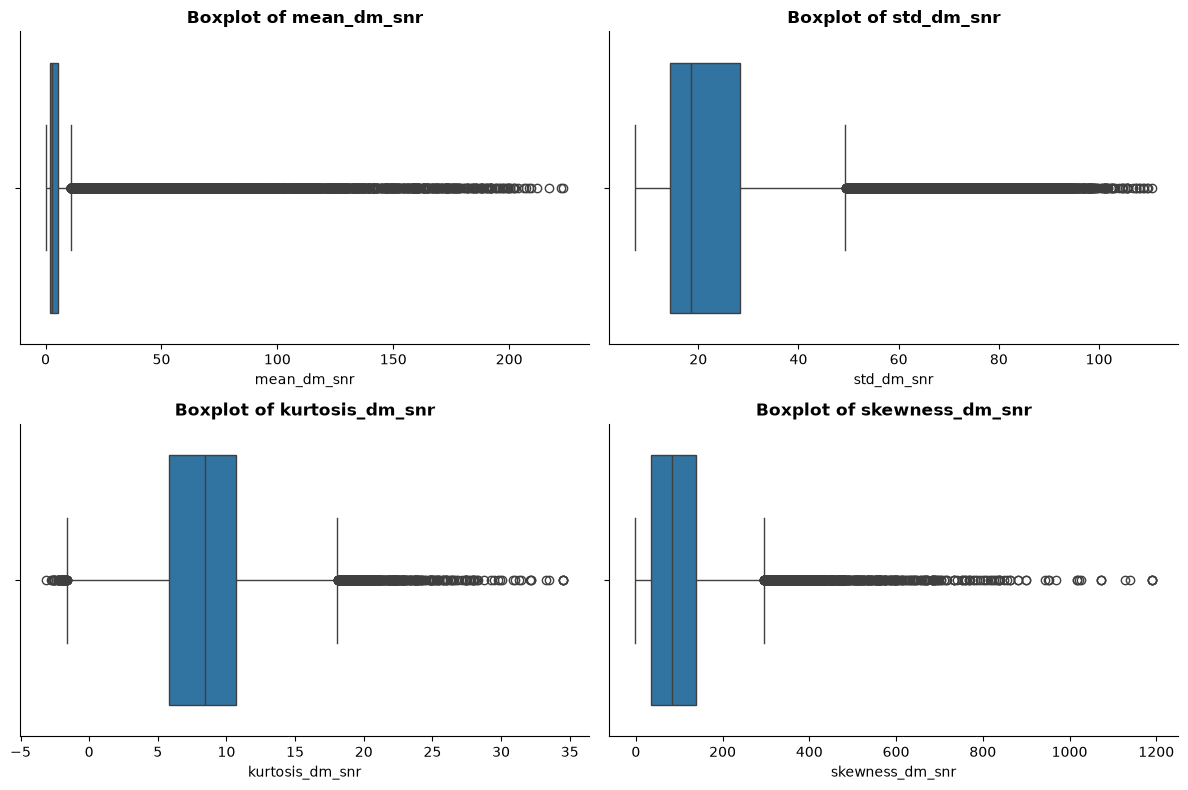

mean_dm_snr:
IQR: 3.54
Lower bound: -3.39
Upper bound: 10.78
Outliers: 2927 (16.35%)

std_dm_snr:
IQR: 13.99
Lower bound: -6.55
Upper bound: 49.41
Outliers: 2346 (13.11%)

kurtosis_dm_snr:
IQR: 4.92
Lower bound: -1.60
Upper bound: 18.09
Outliers: 487 (2.72%)

skewness_dm_snr:
IQR: 104.35
Lower bound: -121.56
Upper bound: 295.83
Outliers: 901 (5.03%)



In [13]:
analyze_outliers(df, dm_snr_features)

### 3.4. Univariate: DM-SNR Curve — findings

- `mean_dm_snr` and `skewness_dm_snr` exhibit extreme positive skewness (max values reach ~223 and ~1191, respectively).
- `kurtosis_dm_snr` displays a bimodal-like structure with a distinct low-value mode (0–2) and primary peak (~8–10), reflecting heterogeneous noise/signal sub-populations.
- Outlier percentages for `mean_dm_snr` (16.35%) and `std_dm_snr` (13.11%) are high and capture broad dispersion responses rather than corrupted data.
- -> Distance-based and linear models will require monotonic compression (e.g., Yeo-Johnson / log1p) to prevent DM features from dominating distance calculations.
- -> Tree-based models (XGBoost, LightGBM, CatBoost) should leverage the bimodal thresholding of `kurtosis_dm_snr` naturally without scaling.

## 4. Bivariate: feature vs target

This section examines each feature split by target class. Features that show
clear separation between pulsar and non-pulsar distributions are strong
candidates for high feature importance in the models.

### 4.1. Bivariate: Integrated pulse profile

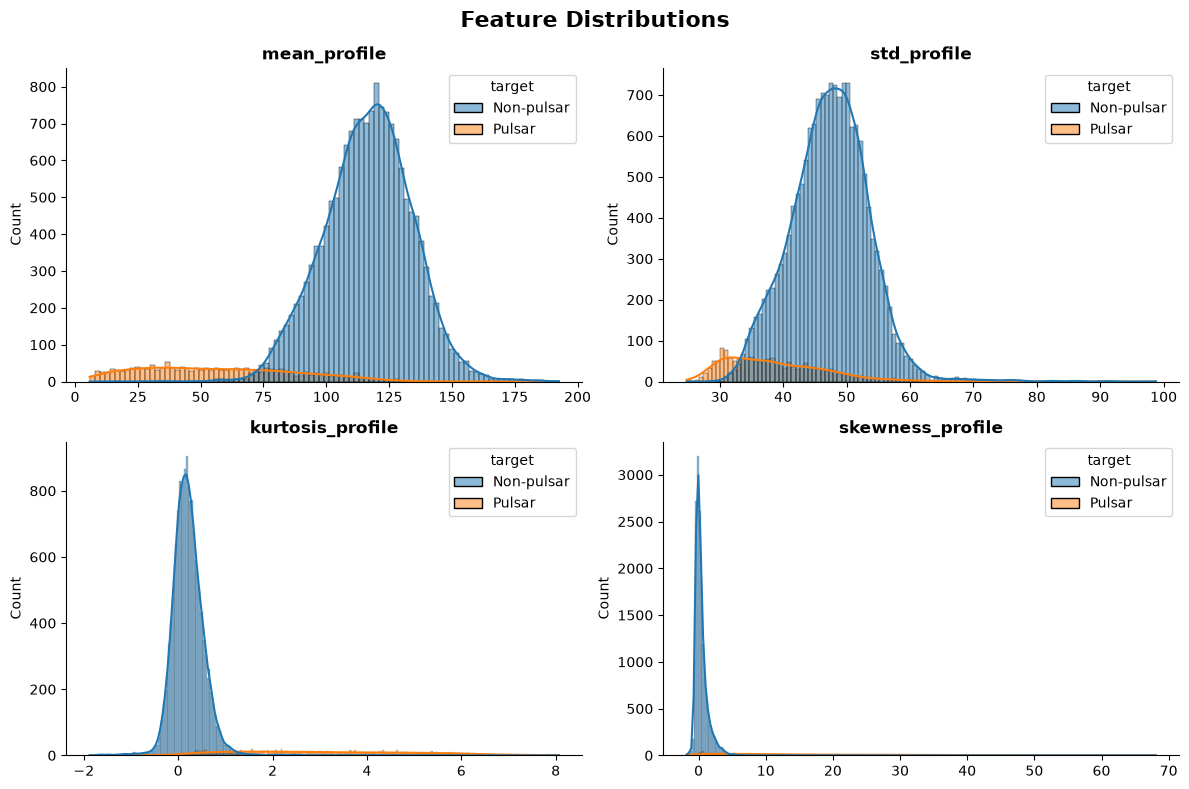

In [14]:
plot_feature_distributions(df_plot, integrated_pulse_features, hue="target")

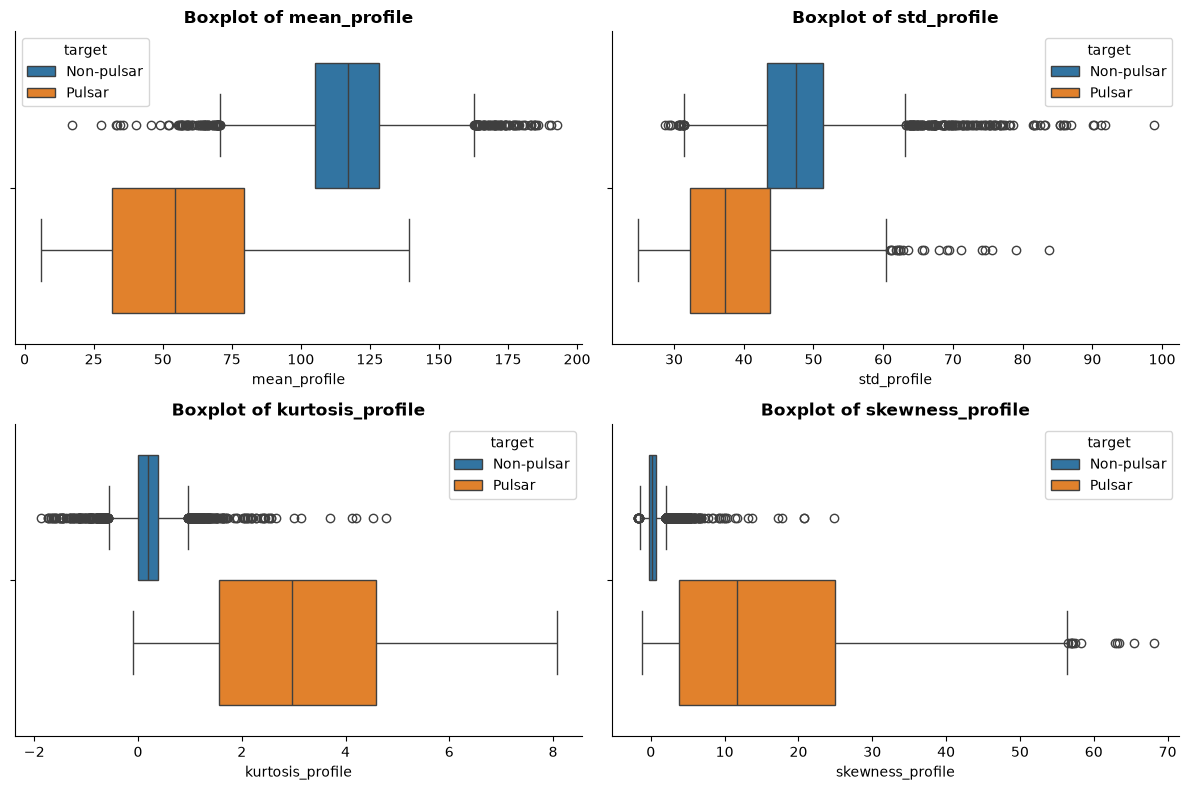

mean_profile | class Non-pulsar:
IQR: 23.03
Lower bound: 70.71
Upper bound: 162.83
Outliers: 142 (0.87%)

mean_profile | class Pulsar:
IQR: 47.50
Lower bound: -39.47
Upper bound: 150.53
Outliers: 0 (0.00%)

std_profile | class Non-pulsar:
IQR: 7.93
Lower bound: 31.49
Upper bound: 63.21
Outliers: 150 (0.92%)

std_profile | class Pulsar:
IQR: 11.47
Lower bound: 15.07
Upper bound: 60.97
Outliers: 21 (1.28%)

kurtosis_profile | class Non-pulsar:
IQR: 0.38
Lower bound: -0.57
Upper bound: 0.97
Outliers: 392 (2.41%)

kurtosis_profile | class Pulsar:
IQR: 3.03
Lower bound: -2.99
Upper bound: 9.13
Outliers: 0 (0.00%)

skewness_profile | class Non-pulsar:
IQR: 0.89
Lower bound: -1.55
Upper bound: 1.99
Outliers: 1078 (6.63%)

skewness_profile | class Pulsar:
IQR: 21.08
Lower bound: -27.81
Upper bound: 56.50
Outliers: 12 (0.73%)



In [15]:
analyze_outliers(df_plot, integrated_pulse_features, hue="target")

### 4.2. Bivariate: Integrated Pulse Profile — findings

- `kurtosis_profile` and `skewness_profile` exhibit near-zero IQR overlap between classes: pulsar medians (~3.0 and ~12.0) are orders of magnitude higher than noise medians (~0.2 and ~0.2).
- -> These two features will likely serve as primary split nodes in tree models and top contributors to feature importance.
- `mean_profile` provides clear negative separation (pulsar median ~55 vs noise median ~117), confirming that narrow pulses produce lower integrated baseline intensity.
- `std_profile` has significant inter-class overlap in the [35, 50] range -> weakest standalone predictor in the profile group, useful only in combination with other features.
- Intra-class IQR shows 0.00% outliers for pulsars on `mean_profile` and `kurtosis_profile` -> pulsar observations form a distinct, broad distribution rather than corrupted noise points.

### 4.3. Bivariate: DM-SNR Curve

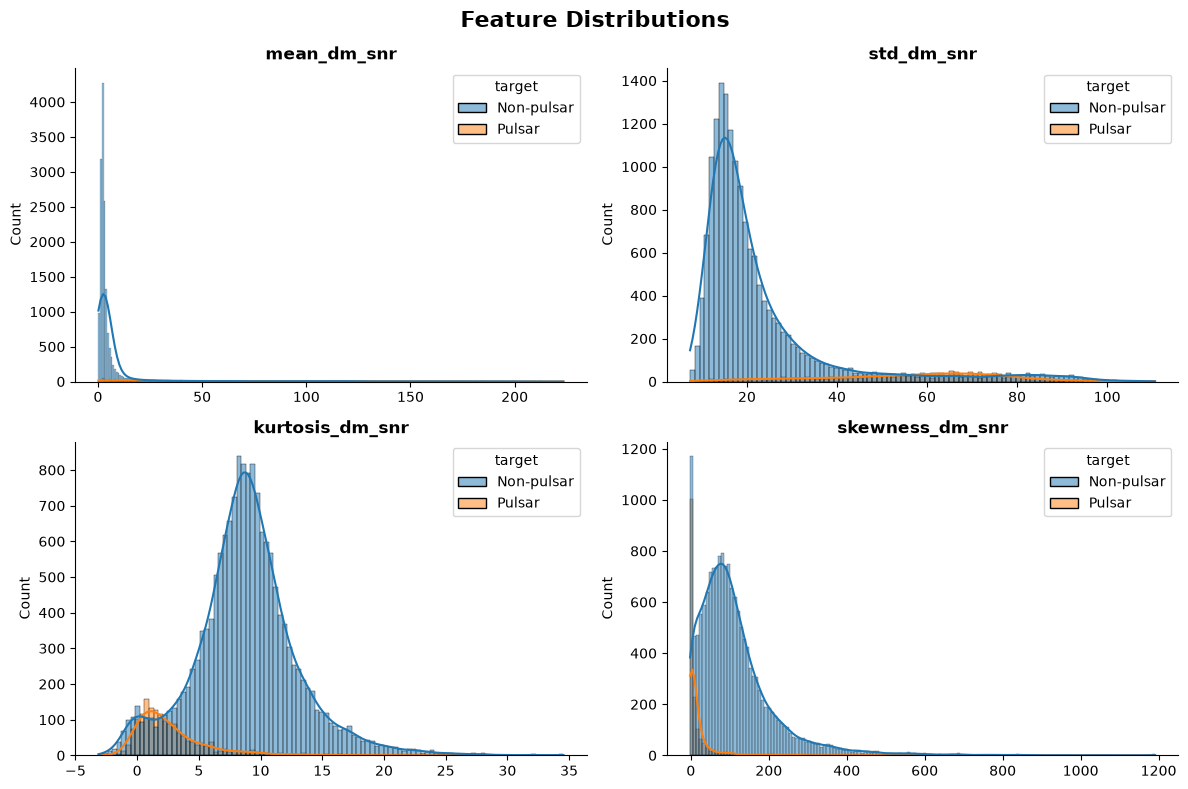

In [16]:
plot_feature_distributions(df_plot, dm_snr_features, hue="target")

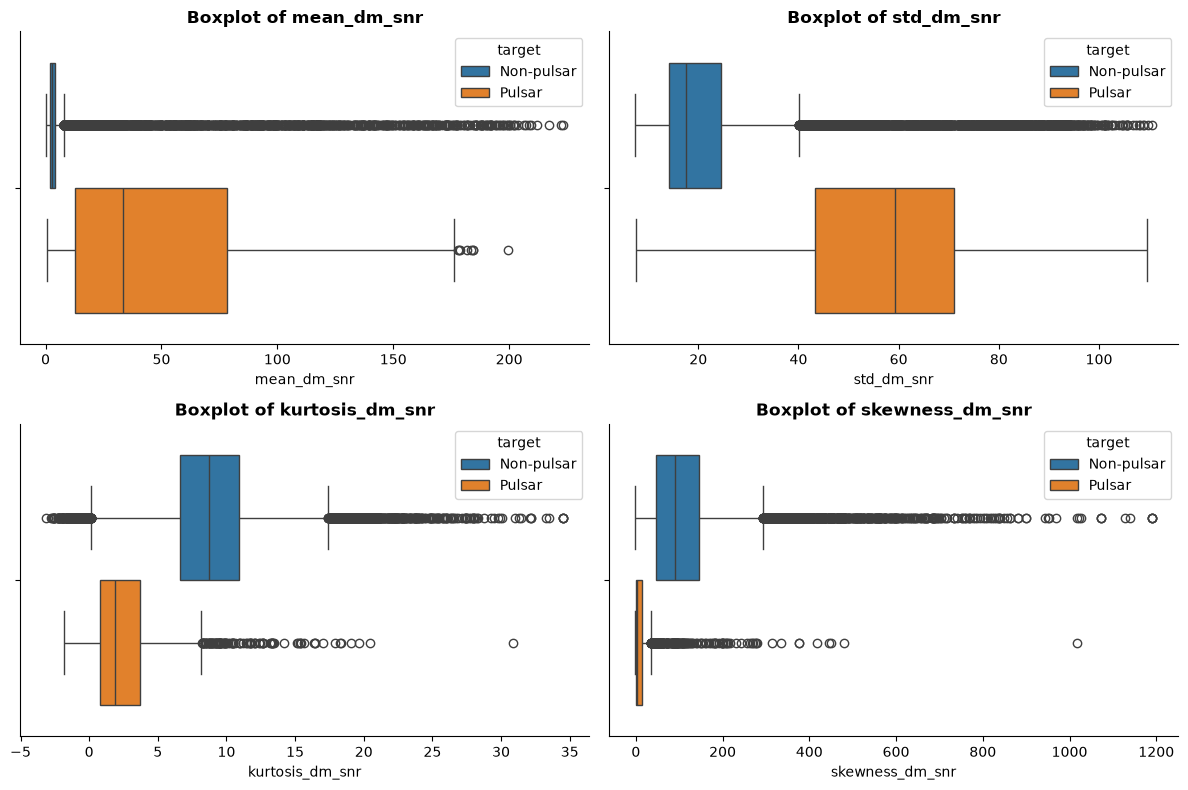

mean_dm_snr | class Non-pulsar:
IQR: 2.37
Lower bound: -1.70
Upper bound: 7.78
Outliers: 2118 (13.03%)

mean_dm_snr | class Pulsar:
IQR: 65.55
Lower bound: -85.57
Upper bound: 176.64
Outliers: 8 (0.49%)

std_dm_snr | class Non-pulsar:
IQR: 10.38
Lower bound: -1.43
Upper bound: 40.09
Outliers: 1668 (10.26%)

std_dm_snr | class Pulsar:
IQR: 27.65
Lower bound: 1.86
Upper bound: 112.46
Outliers: 0 (0.00%)

kurtosis_dm_snr | class Non-pulsar:
IQR: 4.32
Lower bound: 0.14
Upper bound: 17.41
Outliers: 999 (6.14%)

kurtosis_dm_snr | class Pulsar:
IQR: 2.95
Lower bound: -3.67
Upper bound: 8.14
Outliers: 104 (6.35%)

skewness_dm_snr | class Non-pulsar:
IQR: 98.25
Lower bound: -99.79
Upper bound: 293.20
Outliers: 908 (5.58%)

skewness_dm_snr | class Pulsar:
IQR: 13.70
Lower bound: -20.78
Upper bound: 34.02
Outliers: 212 (12.93%)



In [17]:
analyze_outliers(df_plot, dm_snr_features, hue="target")

### 4.4. Bivariate: DM-SNR Curve — findings

- `mean_dm_snr` and `std_dm_snr` effectively separate classes by shifting the pulsar distribution significantly to the right (pulsar medians ~35 and ~60 vs noise medians ~2 and ~18).
- `kurtosis_dm_snr` and `skewness_dm_snr` show an inverse pattern: non-pulsar noise exhibits high kurtosis and extended right tails, whereas real pulsars are tightly bounded at lower values.
- Inter-class IQR overlap for `std_dm_snr` and `mean_dm_snr` is moderate, but extreme outliers in the non-pulsar class represent high-energy RFI (Radio Frequency Interference) mimicking true signals.
- -> Tree-based models will leverage `kurtosis_dm_snr` and `mean_dm_snr` as primary discriminators to filter out RFI spikes.
- -> Scaling (`RobustScaler`) remains critical for distance-based models due to the massive scale disparity in `skewness_dm_snr` (up to ~1,200).

## 5. Correlation analysis

This section examines pairwise Pearson (linear) and Spearman (monotonic)
correlations — both between features (multicollinearity, relevant for linear
models) and between features and the target (single-feature predictive power).

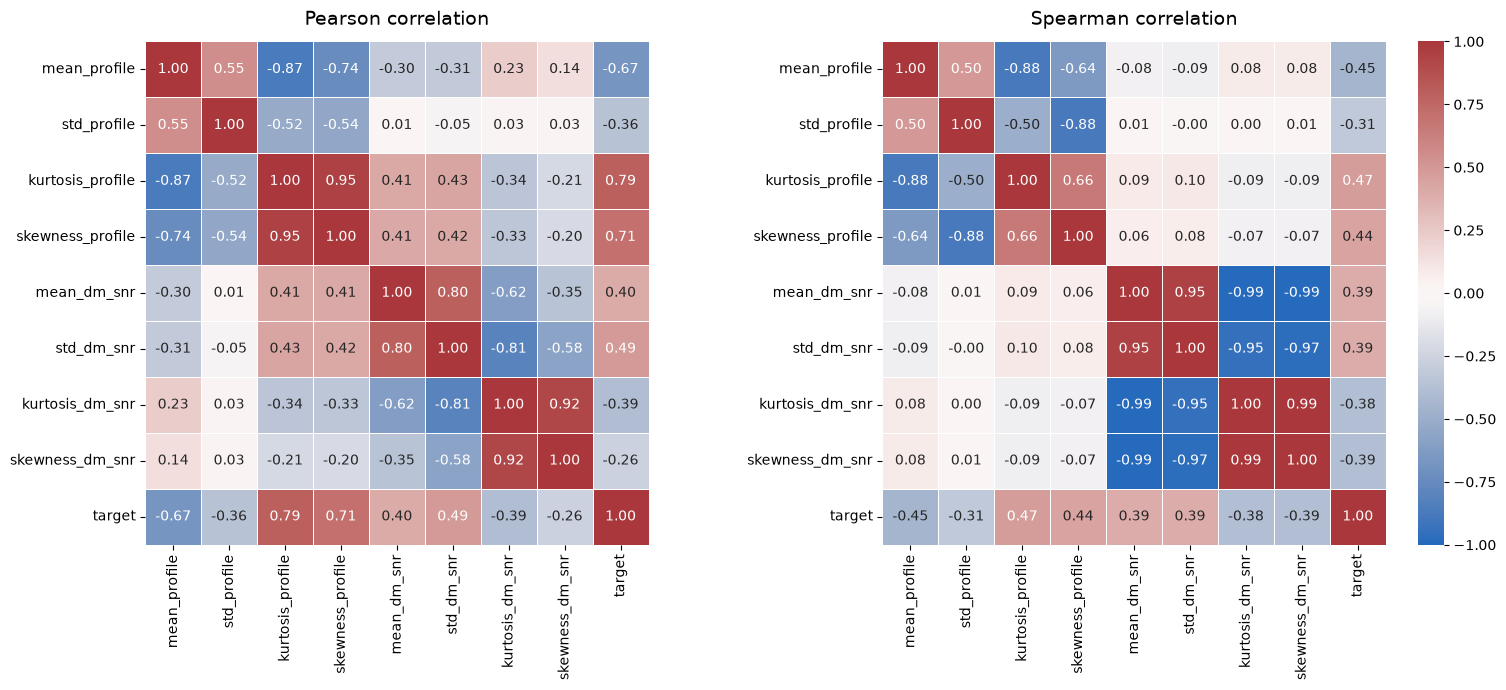

In [18]:
corr_pearson = df.corr(method="pearson", numeric_only=True)
corr_spearman = df.corr(method="spearman", numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    corr_pearson,
    ax=axes[0],
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=False
)

axes[0].set_title("Pearson correlation", fontsize=14, pad=12)

sns.heatmap(
    corr_spearman,
    ax=axes[1],
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=True
)

axes[1].set_title("Spearman correlation", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

### 5.1. Correlation Analysis — findings

- Extreme rank multicollinearity across all DM-SNR features: pairwise Spearman $|\rho| \ge 0.95$ (up to $0.99$ between `kurtosis_dm_snr` and `skewness_dm_snr`), indicating high informational redundancy.
- Strong collinearity in pulse profile features: `kurtosis_profile` and `skewness_profile` share $r = 0.95$, while `mean_profile` strongly negatively correlates with `kurtosis_profile` ($r = -0.87$).
- Top linear target correlates: `kurtosis_profile` ($r = 0.79$) and `mean_profile` ($r = -0.67$).
- -> Linear models (Logistic Regression) will suffer from variance inflation: require $L_2$ regularization (Ridge) or feature pruning/PCA.
- -> Tree ensembles (XGBoost, LightGBM) will handle collinearity automatically, though feature importance metrics (MDI / Gain) will be shared across redundant DM features.

## 6. Summary & Modeling Strategy

### 6.1. Key Findings
1. **Target Imbalance**: 9.16% pulsars vs 90.84% non-pulsars (~1:10 ratio). Baseline dummy accuracy (~90.8%) is uninformative.
2. **Discriminative Power**: `kurtosis_profile`, `skewness_profile`, and `mean_profile` are the dominant single-feature predictors with minimal class overlap.
3. **Multicollinearity**: The 4 DM-SNR features are near-perfectly monotonically collinear ($|\rho| \ge 0.95$), representing redundant views of the same physical response.
4. **Outlier Nature**: Extreme values in right tails are genuine pulsar observations; trimming them would discard the positive class.

### 6.2. Action Plan for Modeling
- **Validation**: Stratified 5-Fold Cross-Validation (`StratifiedKFold`) to preserve class proportions.
- **Evaluation Metrics**: Primary: PR-AUC (Average Precision) and F1-score / Recall; Secondary: ROC-AUC.
- **Preprocessing Pipeline**:
  - *For linear/distance models (Logistic Regression, SVM, kNN)*: Apply Yeo-Johnson / `RobustScaler` to handle extreme scales, and $L_2$ regularization to control collinearity.
  - *For tree ensembles (Random Forest, XGBoost, LightGBM)*: Train directly on raw unscaled features without outlier removal.
- **Imbalance Handling**: Benchmark cost-sensitive learning (`scale_pos_weight` / `class_weight='balanced'`) against precision-recall threshold tuning.